# Análisis de los datos

In [2]:
from extraccion import minioFunctions as mf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, TimeSeriesSplit

Este nuevo notebook de análisis contiene las nuevas variables (temperatura del suelo y distancia a la civilización), así como las nuevas zonas de no incendio creadas y sin los incendios de Ucrania. 

### **Características de las variables**

In [4]:
df_final = mf.bajar_fichero(mf.crear_cliente(), "grupo3/cleaned/MINI.parquet", "df")

Dataframe importado correctamente


**COMPOSICIÓN DEL DATASET**

Las variables son:

In [5]:
print(f"Variables: {df_final.columns}")

Variables: Index(['lat', 'lon', 'date', 'soil_temp', 'final', 'elevacion_centro',
       'grados', 'porcentaje', 'temp_mean', 'temp_max', 'temp_min',
       'humidity_mean', 'precipitation', 'wind_speed_max', 'wind_gusts_max',
       'pressure_mean', 'cloud_cover', 'radiation', 'evapotranspiration',
       'sunshine_seconds', 'NDVI', 'NDWI', 'dist_civ', 'dia_sin', 'dia_cos'],
      dtype='str')


Total de filas y proporción de incendios y no incendios:

In [4]:
total = len(df_final)
total_incendios = len(df_final[df_final['final'] == 1])
total_no_incendios = len(df_final[df_final['final'] == 0])
print(f"La longitud total de los datos es de: {total}")
print(f"Proporción de incendios: {np.round(total_incendios * 100 / total, 2)} %")
print(f"Proporción de no incendios: {np.round(total_no_incendios * 100 / total, 2)} %")

La longitud total de los datos es de: 73324
Proporción de incendios: 2.76 %
Proporción de no incendios: 97.24 %


Representación primeras filas del dataset:

In [5]:
print(df_final.head(10))

         lat        lon       date  soil_temp  final  elevacion_centro  \
0  41.686835  -7.745495 2022-01-01       7.05      0        925.704529   
1  44.071644  -0.061773 2022-01-01       8.71      0        154.857666   
2  42.536240  23.061034 2022-01-01       0.94      0        990.911926   
3  44.038693  -0.066743 2022-01-01       8.71      0        142.952698   
4  41.876496   2.998870 2022-01-01       9.29      0        294.274353   
5  42.582694   8.965271 2022-01-01       9.64      0        113.122955   
6  38.822523  -9.393581 2022-01-01      12.23      0        161.298645   
7  40.396291  29.373938 2022-01-01       6.55      0        444.201660   
8  48.318117   8.499071 2022-01-01       6.03      0        687.978943   
9  41.866246   2.905642 2022-01-01       9.29      0        137.516983   

      grados  porcentaje  temp_mean  temp_max  ...  pressure_mean  \
0  12.185408   21.594108       10.7      14.7  ...          917.6   
1   0.512293    0.894143        9.9      18.4  

**VARIABLE OBJETIVO**

La varible objetivo es una variable binaria --> 0 indica no-incendio y 1, incendio.

In [6]:
print(df_final['final'].unique())

[0 1]


**INFORMACIÓN DEL TIPO DE VARIABLES**

In [7]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 73324 entries, 0 to 74257
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 73324 non-null  float64       
 1   lon                 73324 non-null  float64       
 2   date                73324 non-null  datetime64[ns]
 3   soil_temp           73324 non-null  float64       
 4   final               73324 non-null  int64         
 5   elevacion_centro    73324 non-null  float64       
 6   grados              73324 non-null  float64       
 7   porcentaje          73324 non-null  float64       
 8   temp_mean           73324 non-null  float64       
 9   temp_max            73324 non-null  float64       
 10  temp_min            73324 non-null  float64       
 11  humidity_mean       73324 non-null  float64       
 12  precipitation       73324 non-null  float64       
 13  wind_speed_max      73324 non-null  float64       
 14  wind_g

**INFORMACIÓN ESTADÍSTICA DE LAS VARIABLES**

Evaluar la distribución de la variable objetivo (porque es binaria) y de la fecha, y su información estadística resulta irrelevante.

Eliminamos también la latitud y longitud, ya que posteriormente se realizará un gráfico en forma de mapa.

Más tarde se hará un análisis de incendios y de datos basado en los meses.

In [8]:
df = df_final.drop(columns = ['final', 'date', 'lat', 'lon']) 
df.describe()

,soil_temp,elevacion_centro,grados,porcentaje,temp_mean,temp_max,temp_min,humidity_mean,precipitation,wind_speed_max,wind_gusts_max,pressure_mean,cloud_cover,radiation,evapotranspiration,sunshine_seconds,NDVI,NDWI,dist_civ
count,73324.000000,73324.000000,73324.000000,73324.000000,73324.000000,73324.000000,73324.000000,73324.000000,73324.000000,73324.000000,73324.000000,73324.000000,73324.000000,73324.000000,73324.000000,73324.000000,73324.000000,73324.000000,73324.000000
mean,12.676155,406.705417,6.648315,12.051190,12.105871,16.889452,7.655568,71.119306,2.120528,16.626120,36.851357,969.343643,53.787655,14.740786,2.802636,31529.635640,0.448814,-0.443745,31.738497
std,9.223744,416.036299,7.701329,14.708066,8.951114,10.038098,8.153304,15.984474,5.644889,6.591792,13.297581,46.305721,33.319366,8.527732,2.054057,15880.322625,0.247053,0.208728,77.405882
min,-12.870000,-4.875012,0.000198,0.000345,-25.600000,-22.800000,-30.000000,9.000000,0.000000,1.600000,6.500000,646.800000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.043730
25%,5.590000,110.396147,0.988166,1.724846,5.900000,9.900000,2.000000,61.000000,0.000000,11.800000,27.400000,946.600000,24.000000,7.630000,1.100000,22154.637500,0.238178,-0.610388,3.786722
50%,12.010000,242.983597,3.506872,6.128301,12.000000,16.700000,7.800000,73.000000,0.000000,15.700000,34.900000,984.800000,56.000000,14.250000,2.350000,34592.300000,0.446994,-0.455482,7.309162
75%,19.280000,597.006821,9.817273,17.304047,18.500000,24.000000,13.500000,83.000000,1.500000,20.400000,43.900000,1002.600000,85.000000,22.270000,4.220000,44260.330000,0.658114,-0.304858,14.264590
max,40.070000,3606.814453,61.469063,183.940168,39.900000,48.000000,34.400000,100.000000,171.200000,63.400000,145.400000,1045.800000,100.000000,32.850000,12.710000,74861.440000,1.000000,1.000000,553.672676


**DISTRIBUCIÓN DE LAS VARIABLES NUMÉRICAS**

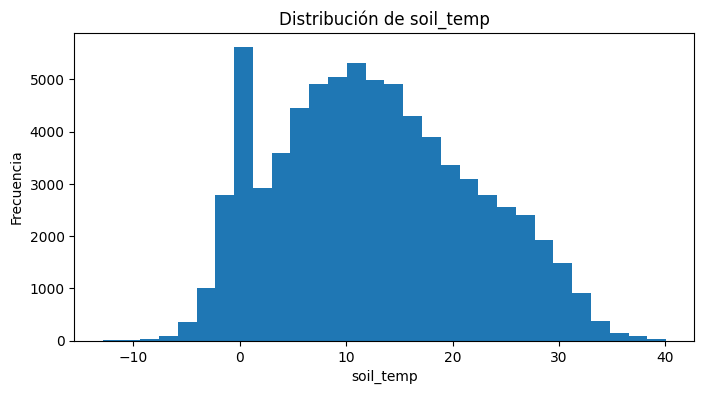

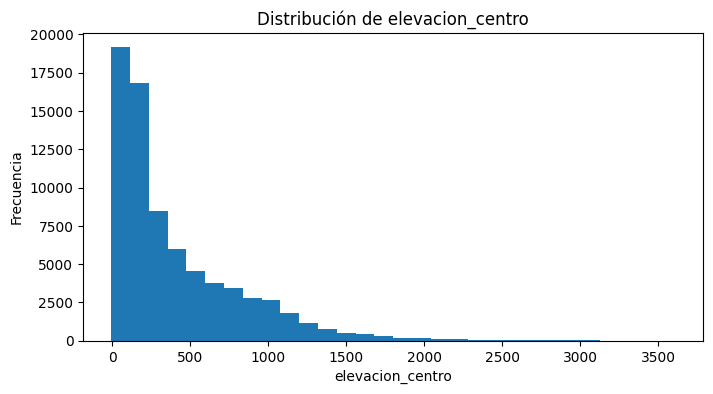

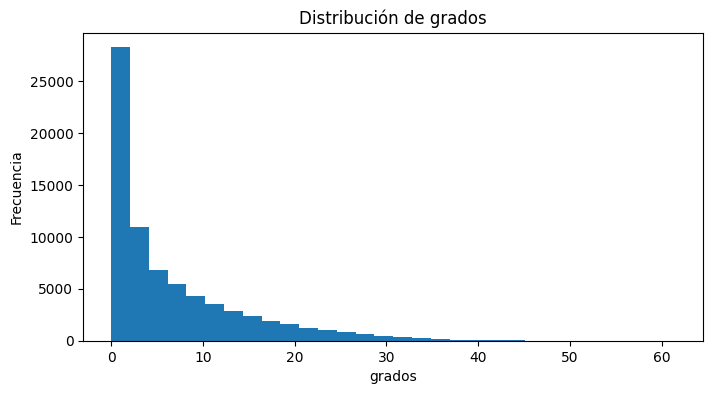

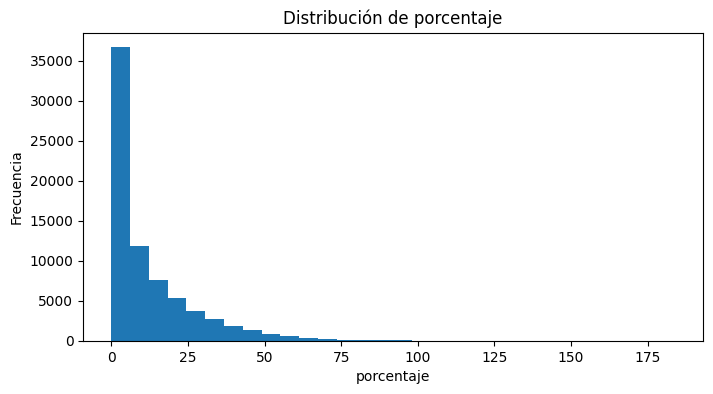

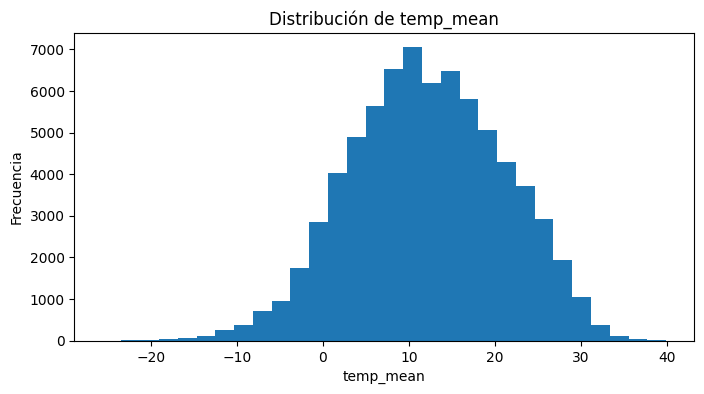

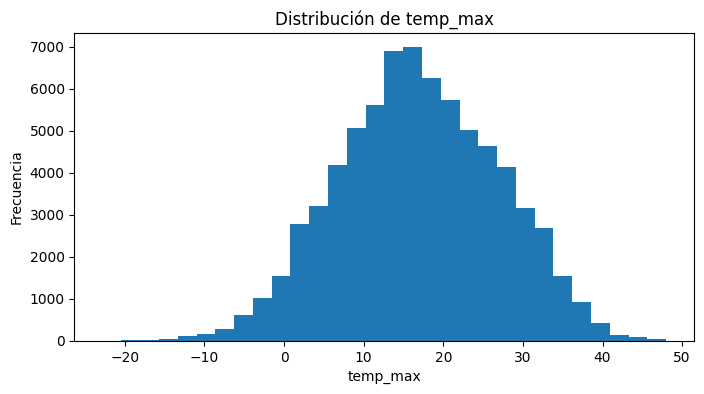

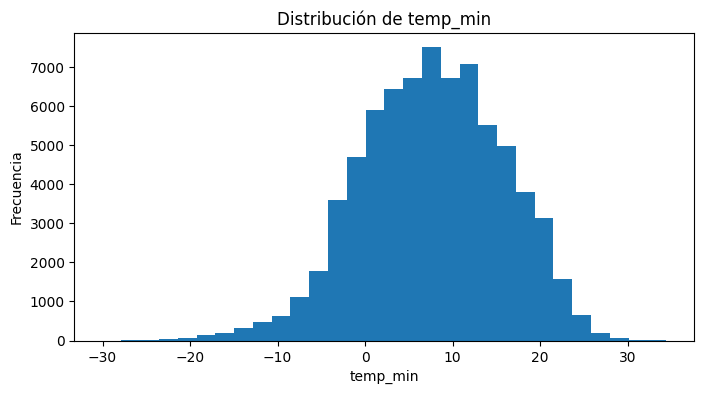

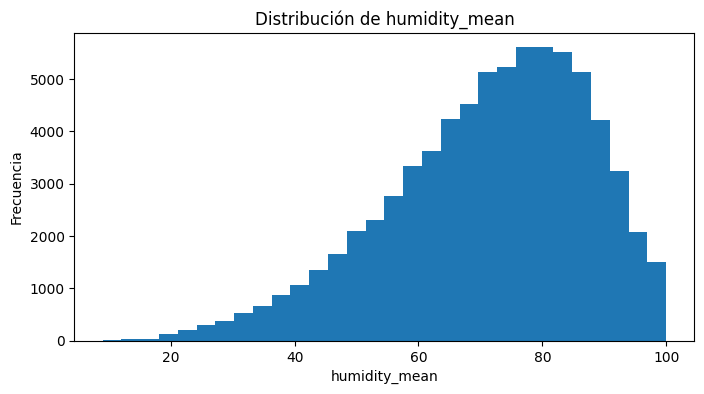

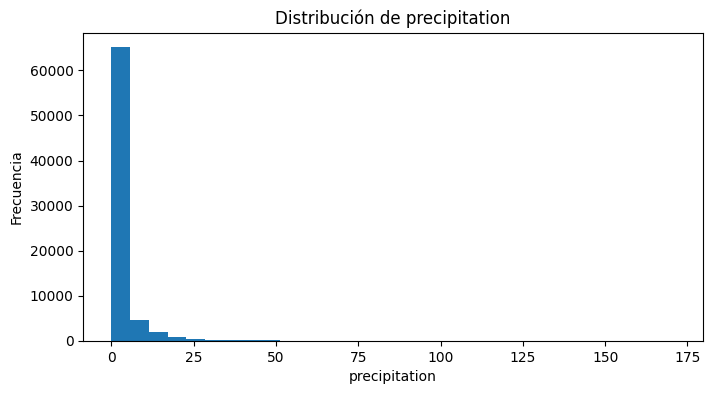

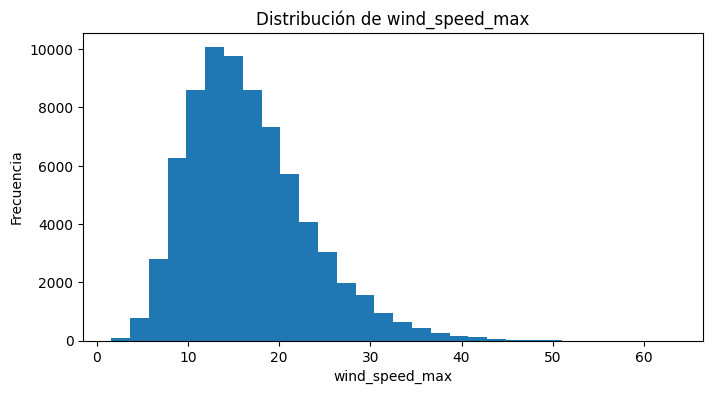

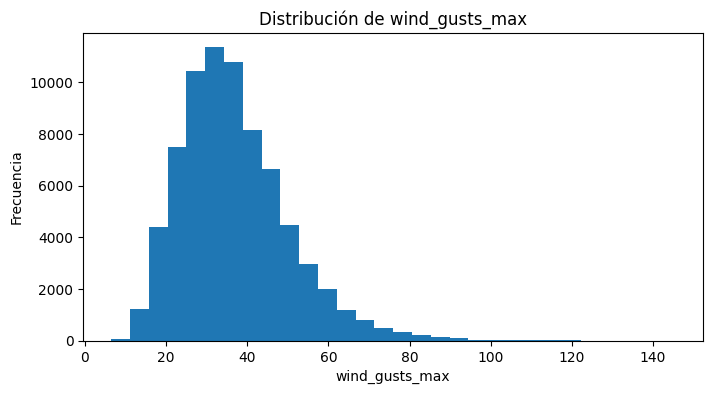

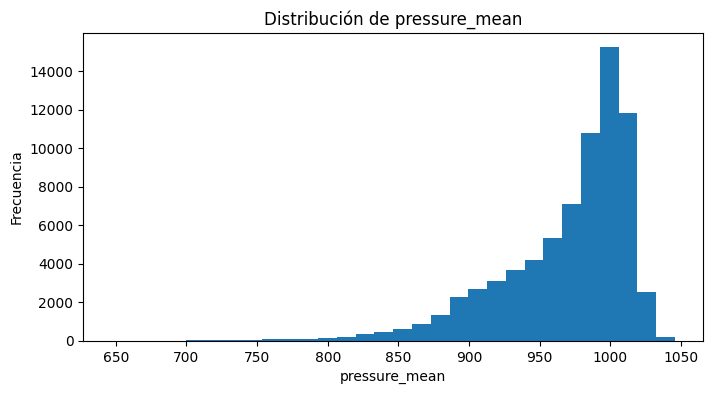

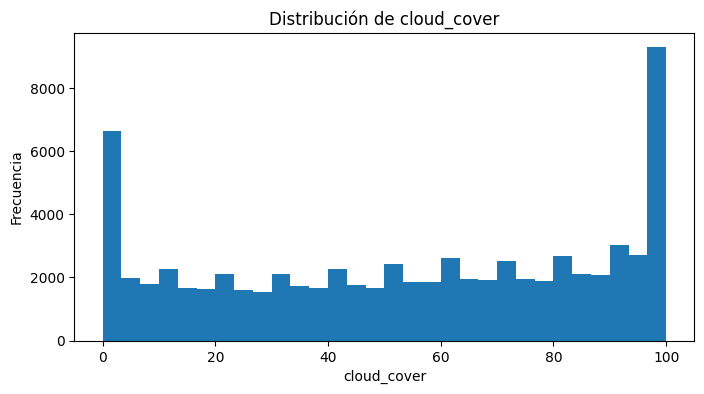

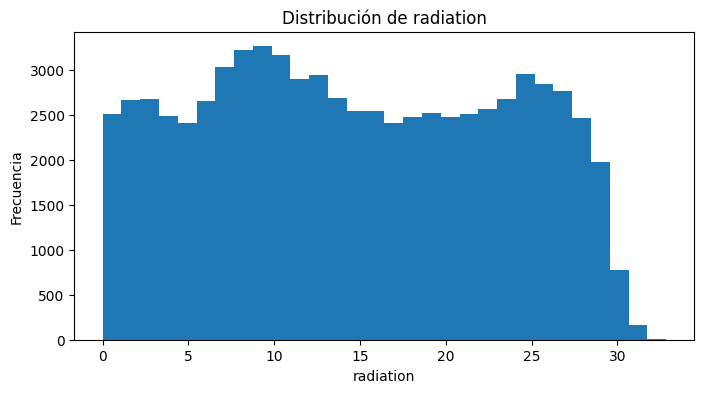

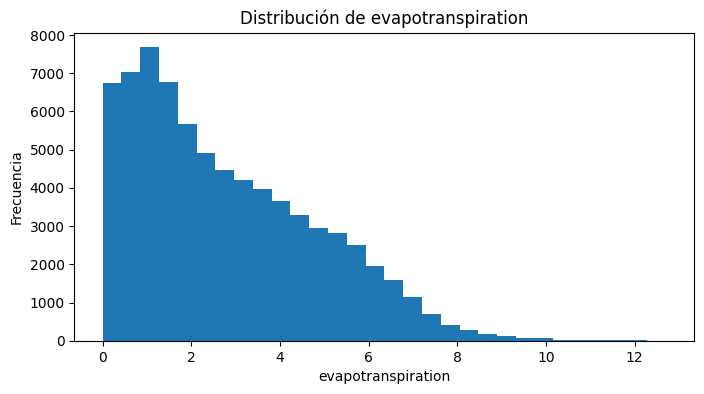

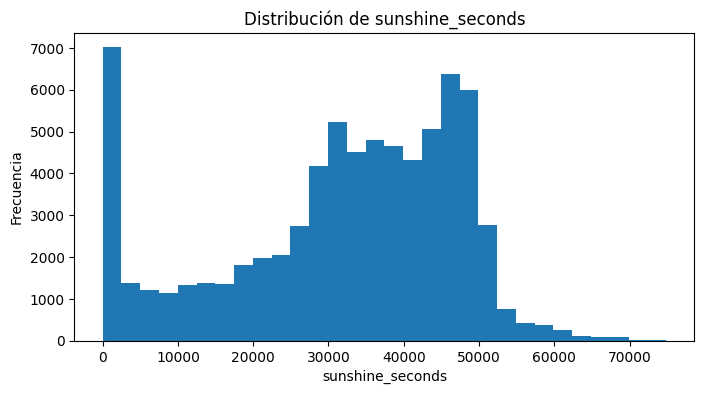

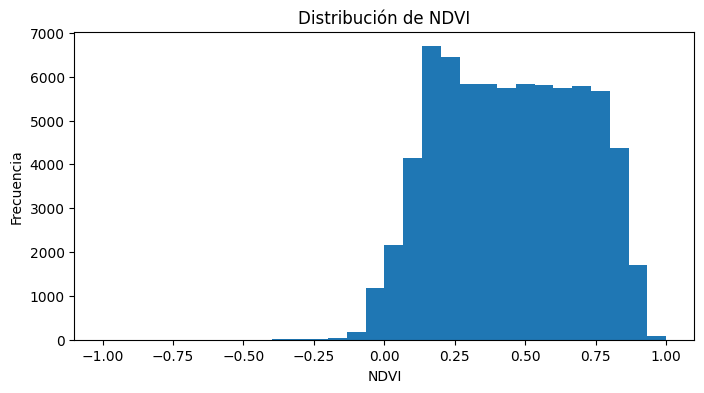

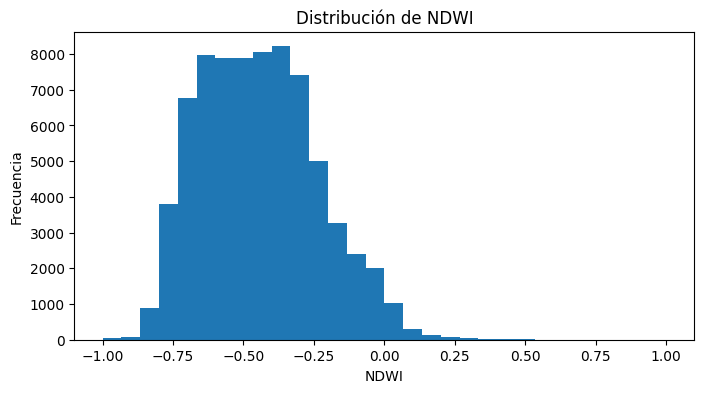

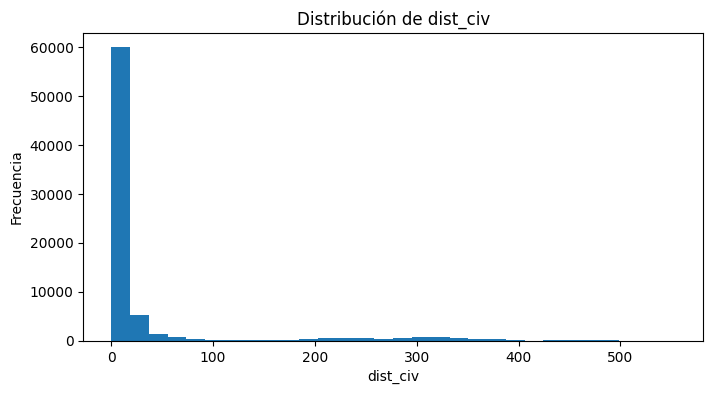

In [9]:
for col in df.columns:
    plt.figure(figsize=(8, 4))
    df[col].hist(bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(False)
    plt.show()

**ANÁLISIS DE LA PRESENCIA DE OUTLIERS**

**Outliers en datos de incendio:**

In [10]:
def detectar_outliers(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    outliers = data[(data[columna] < limite_inf) | (data[columna] > limite_sup)]
    return outliers, limite_inf, limite_sup

df_inc = df_final[df_final['final'] == 1].drop(columns = ['lat', 'lon', 'date', 'final'])
for col in df_inc.columns:
    outliers, limite_inf, limite_sup = detectar_outliers(df_inc, col)
    print(f"Variable {col}: Detectados {len(outliers)} outliers (fuera del rango {limite_inf:.2f} - {limite_sup:.2f})", '\n')

Variable soil_temp: Detectados 7 outliers (fuera del rango -2.58 - 49.21) 

Variable elevacion_centro: Detectados 56 outliers (fuera del rango -667.10 - 1415.58) 

Variable grados: Detectados 42 outliers (fuera del rango -15.97 - 29.90) 

Variable porcentaje: Detectados 64 outliers (fuera del rango -28.43 - 53.11) 

Variable temp_mean: Detectados 19 outliers (fuera del rango -0.35 - 44.85) 

Variable temp_max: Detectados 23 outliers (fuera del rango 4.50 - 52.50) 

Variable temp_min: Detectados 16 outliers (fuera del rango -5.60 - 37.60) 

Variable humidity_mean: Detectados 2 outliers (fuera del rango 6.50 - 90.50) 

Variable precipitation: Detectados 255 outliers (fuera del rango 0.00 - 0.00) 

Variable wind_speed_max: Detectados 34 outliers (fuera del rango 1.15 - 35.15) 

Variable wind_gusts_max: Detectados 48 outliers (fuera del rango 8.10 - 72.90) 

Variable pressure_mean: Detectados 50 outliers (fuera del rango 857.40 - 1088.40) 

Variable cloud_cover: Detectados 40 outliers (fue

En el caso de precipitation, el rango muestra que el límite inferior y superior son ambos 0, por lo que posiblemente, estos outliers son observaciones de puntos donde ha llovido y aún así se ha producido un incendio. 

**Outliers en datos de no incendio:**

In [11]:
def detectar_outliers(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    outliers = data[(data[columna] < limite_inf) | (data[columna] > limite_sup)]
    return outliers, limite_inf, limite_sup

df_no_inc = df_final[df_final['final'] == 0].drop(columns = ['lat', 'lon', 'date', 'final'])
for col in df_inc.columns:
    outliers, limite_inf, limite_sup = detectar_outliers(df_no_inc, col)
    print(f"Variable {col}: Detectados {len(outliers)} outliers (fuera del rango {limite_inf:.2f} - {limite_sup:.2f})", '\n')

Variable soil_temp: Detectados 9 outliers (fuera del rango -14.64 - 38.91) 

Variable elevacion_centro: Detectados 2625 outliers (fuera del rango -617.82 - 1323.73) 

Variable grados: Detectados 3611 outliers (fuera del rango -12.18 - 22.92) 

Variable porcentaje: Detectados 4090 outliers (fuera del rango -21.50 - 40.41) 

Variable temp_mean: Detectados 270 outliers (fuera del rango -13.05 - 36.95) 

Variable temp_max: Detectados 258 outliers (fuera del rango -10.90 - 44.30) 

Variable temp_min: Detectados 475 outliers (fuera del rango -15.05 - 30.15) 

Variable humidity_mean: Detectados 632 outliers (fuera del rango 29.00 - 117.00) 

Variable precipitation: Detectados 10809 outliers (fuera del rango -2.40 - 4.00) 

Variable wind_speed_max: Detectados 1477 outliers (fuera del rango -0.95 - 33.05) 

Variable wind_gusts_max: Detectados 1721 outliers (fuera del rango 2.65 - 68.65) 

Variable pressure_mean: Detectados 2305 outliers (fuera del rango 862.85 - 1086.45) 

Variable cloud_cover:

Se observa que donde más outliers hay es en la variable precipitation. Esto se debe a la presencia de condiciones normales (sin lluvia) en la mayoría de observaciones, y tan solo alguna con observaciones extremas de lluvia. Por lo que no resulta realmente problemático. Lo mismo sucede con las variables que representan el viento. 

Haremos un estudio de variables que consideramos que pueden presentar valores ilógicos tanto meteorológicamente, como geográficamente, dados los outliers detectados y según la tabla estadística obtenida anteriormente.

**Análisis de valores que parecen extraños:**

**1. Valores negativos en elevacion_centro:**

In [12]:
total = len(df_final[df_final['elevacion_centro'] < 0])
total_incendios = len(df_final[(df_final['elevacion_centro'] < 0) & (df_final['final'] == 1)])
total_no_incendios = len(df_final[(df_final['elevacion_centro'] < 0) & (df_final['final'] == 0)])
print(f"Total: {total}")
print(f"Son incendios: {total_incendios}")
print(f"Son no incendios: {total_no_incendios}")

Total: 366
Son incendios: 19
Son no incendios: 347


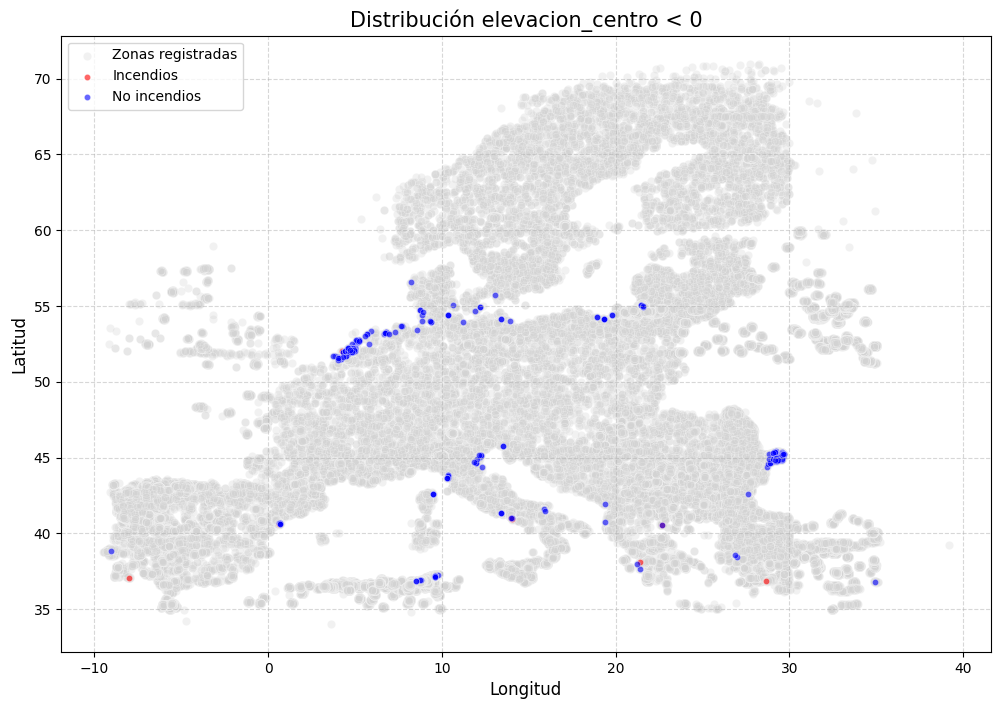

In [13]:
plt.figure(figsize=(12, 8))

df_dist = df_final[df_final['elevacion_centro'] < 0]

sns.scatterplot(data=df_final, x='lon', y='lat', color='lightgrey', alpha=0.3, label='Zonas registradas')

sns.scatterplot(data=df_dist[df_dist['final'] == 1], x='lon', y='lat', color='red', alpha=0.6, s=20, label='Incendios')

sns.scatterplot(data=df_dist[df_dist['final'] == 0], x='lon', y='lat', color='blue', alpha=0.6, s=20, label='No incendios')

plt.title('Distribución elevacion_centro < 0', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Parece que no se trara de errores, ya que todos estos valores parecen localizarse en zona costera, donde la elevación podría haberse medido con unos metros por debajo del nivel del mar.

**2.** **Distribución de temp_max < -20 grados, según latitud y longitud:**

In [14]:
print(f"Total: {len(df_final[df_final['temp_max'] < -20])}")

Total: 17


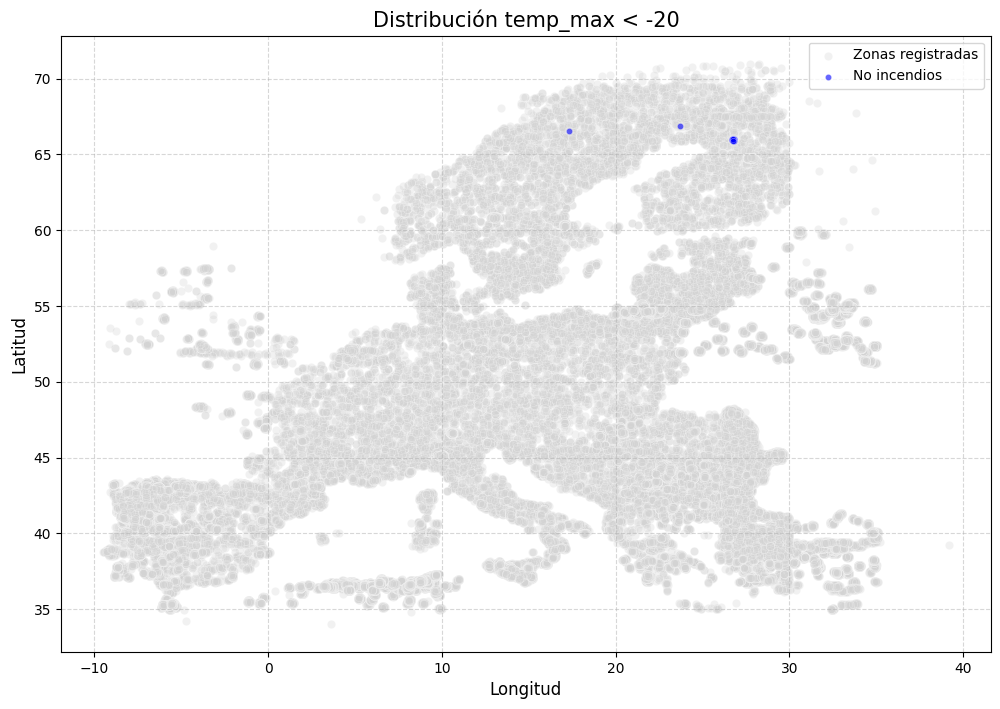

In [15]:
plt.figure(figsize=(12, 8))

df_dist = df_final[df_final['temp_max'] < -20]

sns.scatterplot(data=df_final, x='lon', y='lat', color='lightgrey', alpha=0.3, label='Zonas registradas')

sns.scatterplot(data=df_dist[df_dist['final'] == 1], x='lon', y='lat', color='red', alpha=0.6, s=20, label='Incendios')

sns.scatterplot(data=df_dist[df_dist['final'] == 0], x='lon', y='lat', color='blue', alpha=0.6, s=20, label='No incendios')

plt.title('Distribución temp_max < -20', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**3. Distribución de temp_min < -20 grados, según latitud y longitud:**

In [16]:
print(f"Total: {len(df_final[df_final['temp_min'] < -20])}")

Total: 106


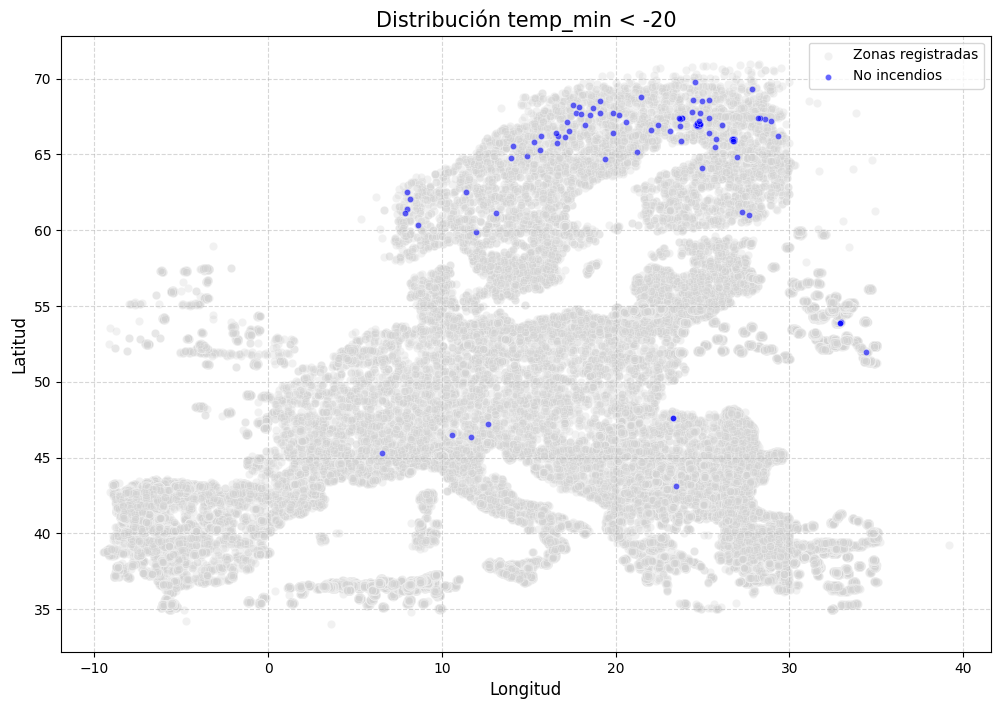

In [17]:
plt.figure(figsize=(12, 8))

df_dist = df_final[df_final['temp_min'] < -20]

sns.scatterplot(data=df_final, x='lon', y='lat', color='lightgrey', alpha=0.3, label='Zonas registradas')

sns.scatterplot(data=df_dist[df_dist['final'] == 1], x='lon', y='lat', color='red', alpha=0.6, s=20, label='Incendios')

sns.scatterplot(data=df_dist[df_dist['final'] == 0], x='lon', y='lat', color='blue', alpha=0.6, s=20, label='No incendios')

plt.title('Distribución temp_min < -20', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**4. Distribución de temp_mean < -20 grados, según latitud y longitud:**

In [18]:
print(f"Total: {len(df_final[df_final['temp_mean'] < -20])}")

Total: 34


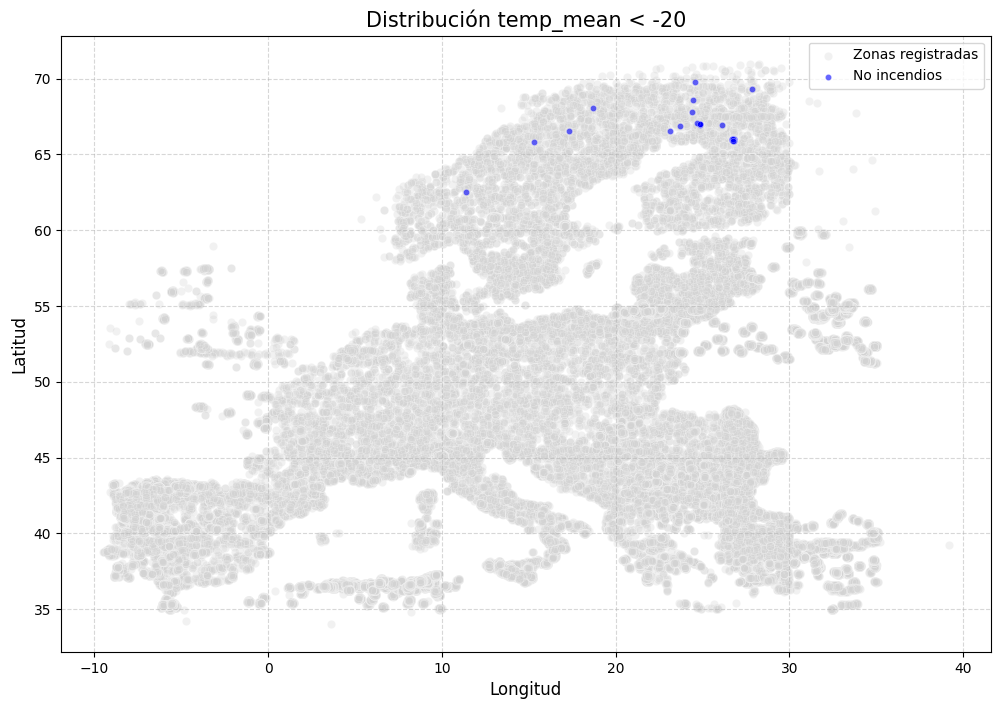

In [19]:
plt.figure(figsize=(12, 8))

df_dist = df_final[df_final['temp_mean'] < -20]

sns.scatterplot(data=df_final, x='lon', y='lat', color='lightgrey', alpha=0.3, label='Zonas registradas')

sns.scatterplot(data=df_dist[df_dist['final'] == 1], x='lon', y='lat', color='red', alpha=0.6, s=20, label='Incendios')

sns.scatterplot(data=df_dist[df_dist['final'] == 0], x='lon', y='lat', color='blue', alpha=0.6, s=20, label='No incendios')

plt.title('Distribución temp_mean < -20', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

No hay presencia de ningún dato de incendio con valores tan bajos de temperatura, por lo que no resulta problemático. 

Además, las zonas donde se localizan esto valores no resultan extrañas. Y no aparecen datos de incendio con esas temperaturas, lo que muestra que no son errores.

**5. Porcentaje > 100:**

In [20]:
total = len(df_final[df_final['porcentaje'] > 100])
total_incendios = len(df_final[(df_final['porcentaje'] > 100) & (df_final['final'] == 1)])
total_no_incendios = len(df_final[(df_final['porcentaje'] > 100) & (df_final['final'] == 0)])
print(f"Total: {total}")
print(f"Son incendios: {total_incendios}")
print(f"Son no incendios: {total_no_incendios}")

Total: 71
Son incendios: 2
Son no incendios: 69


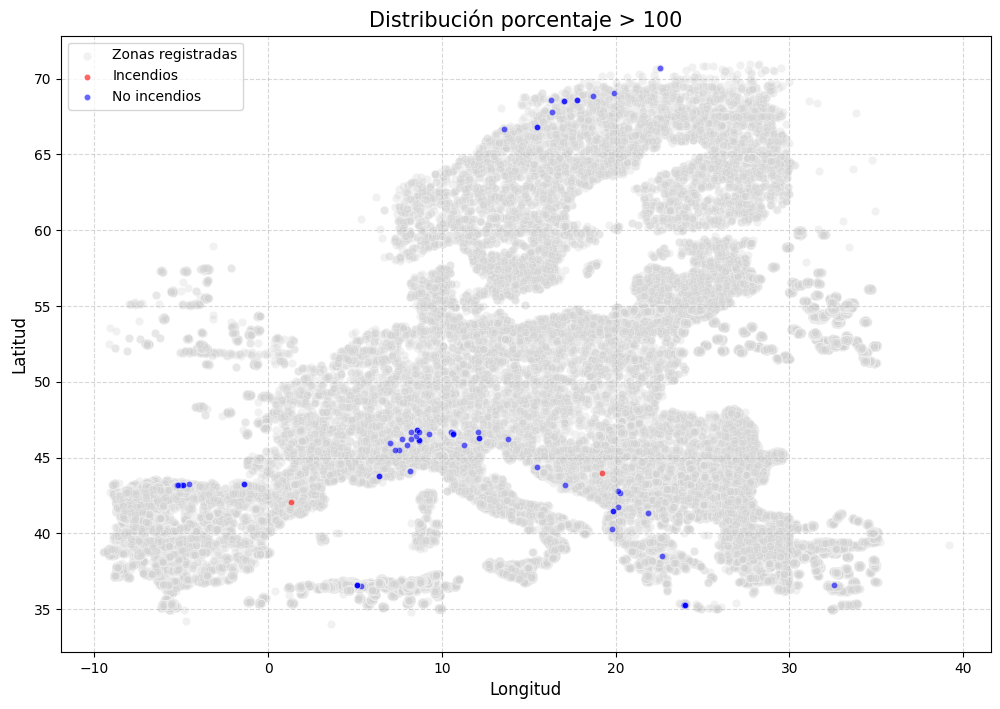

In [21]:
plt.figure(figsize=(12, 8))

df_dist = df_final[df_final['porcentaje'] > 100]

sns.scatterplot(data=df_final, x='lon', y='lat', color='lightgrey', alpha=0.3, label='Zonas registradas')

sns.scatterplot(data=df_dist[df_dist['final'] == 1], x='lon', y='lat', color='red', alpha=0.6, s=20, label='Incendios')

sns.scatterplot(data=df_dist[df_dist['final'] == 0], x='lon', y='lat', color='blue', alpha=0.6, s=20, label='No incendios')

plt.title('Distribución porcentaje > 100', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

No resultan datos preocupantes, porque realmente los puntos detectados se encuentran en zonas con cordilleras, como la cantábrica en España, los Pirineos, los Alpes, etc. 
Valores de porcentaje > 100 representan pendientes mayores que 45º.

**6. NDVI < 0:**

In [22]:
total = len(df_final[df_final['NDVI'] < 0])
total_incendios = len(df_final[(df_final['NDVI'] < 0) & (df_final['final'] == 1)])
total_no_incendios = len(df_final[(df_final['NDVI'] < 0) & (df_final['final'] == 0)])
print(f"Total: {total}")
print(f"Son incendios: {total_incendios}")
print(f"Son no incendios: {total_no_incendios}")

Total: 1448
Son incendios: 25
Son no incendios: 1423


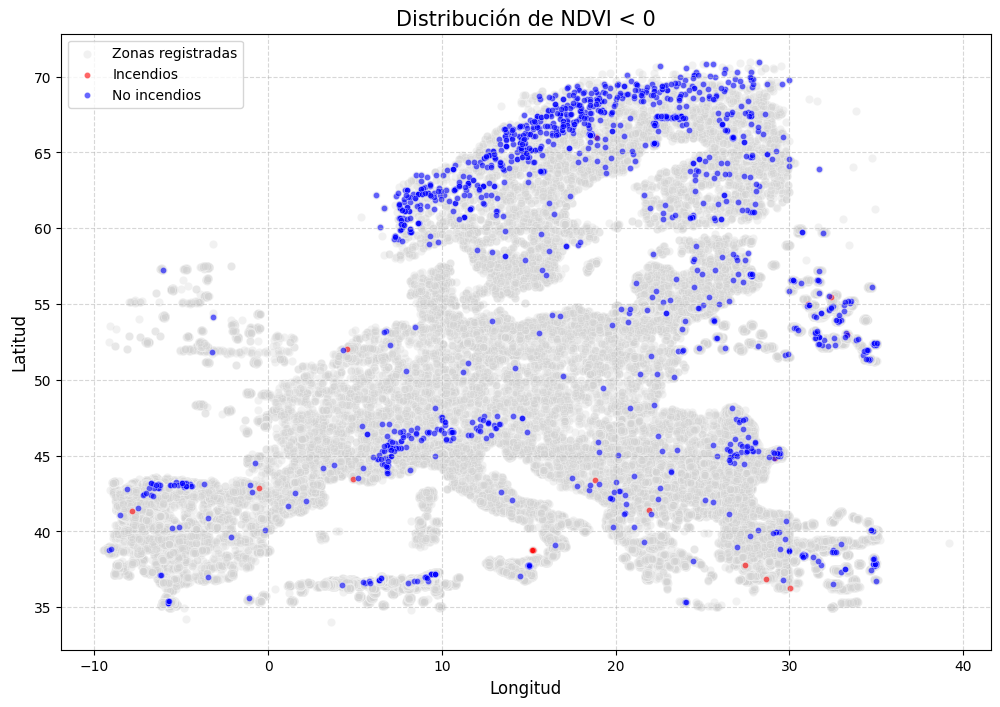

In [23]:
plt.figure(figsize=(12, 8))

df_dist = df_final[df_final['NDVI'] < 0]

sns.scatterplot(data=df_final, x='lon', y='lat', color='lightgrey', alpha=0.3, label='Zonas registradas')

sns.scatterplot(data=df_dist[df_dist['final'] == 1], x='lon', y='lat', color='red', alpha=0.6, s=20, label='Incendios')

sns.scatterplot(data=df_dist[df_dist['final'] == 0], x='lon', y='lat', color='blue', alpha=0.6, s=20, label='No incendios')

plt.title('Distribución de NDVI < 0', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Tampoco resulta preocupante la distribución donde el NDVI es negativo, puesto que, principalmente, estos puntos se encuentran de nuevo localizados en zonas de montaña, donde puede haber presencia de nieve, así como zonas de humedales, donde el píxel ha podido detectar una pequeña presencia de agua. 

Tiene sentido que en esos puntos no haya casi incendios.

**7. Distancia a la civilización:**

En este caso detectamos dónde se encuentran los outliers

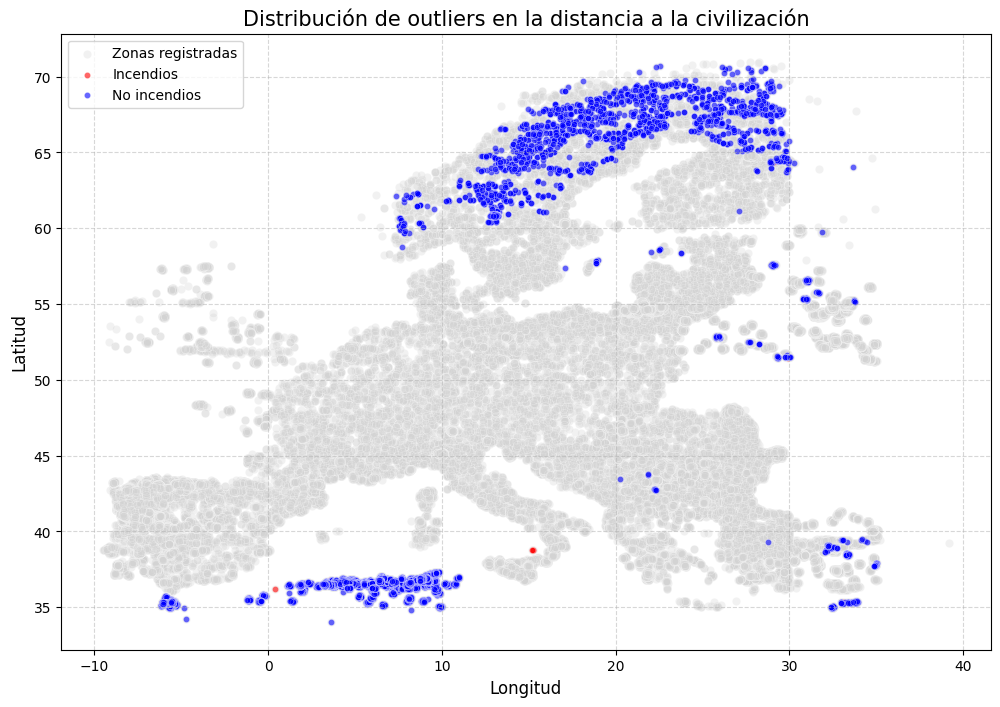

In [26]:
plt.figure(figsize=(12, 8))

df_dist = df_final[(df_final['dist_civ'] < -12.04) | (df_final['dist_civ'] > 30.18)]

sns.scatterplot(data=df_final, x='lon', y='lat', color='lightgrey', alpha=0.3, label='Zonas registradas')

sns.scatterplot(data=df_dist[df_dist['final'] == 1], x='lon', y='lat', color='red', alpha=0.6, s=20, label='Incendios')

sns.scatterplot(data=df_dist[df_dist['final'] == 0], x='lon', y='lat', color='blue', alpha=0.6, s=20, label='No incendios')

plt.title('Distribución de outliers en la distancia a la civilización', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

La gran concentración de puntos azules en el norte (latitud 60-70) coincide con Escandinavia (Noruega, Suecia, Finlandia). Tiene sentido que sean "outliers en distancia a la civilización", ya que son de las zonas más remotas, boscosas y menos pobladas de Europa.

Los puntos azules en el sur (latitud 35) coinciden con el Norte de África. Al ser zonas potencialmente desérticas o rurales, también es lógico que se consideren alejadas de los centros urbanos europeos estándar.

Hay puntos aislados en zonas de montaña o áreas rurales profundas en el este de Europa.

Se observa que tan solo 2 puntos son incendios, lo que apoya nuestra hipótesis de que a mayor distancia a la civilización, menos incendios.

**DISTRIBUCIÓN DE LOS INCENDIOS Y DE LOS DATOS POR LATITUD Y LONGITUD**

Se quiere evaluar si hay una distribución equitativa de los datos, como se pretendía con la obtención de los datos de no incendio, así como evaluar las zonas donde el riesgo de incendio es mayor.

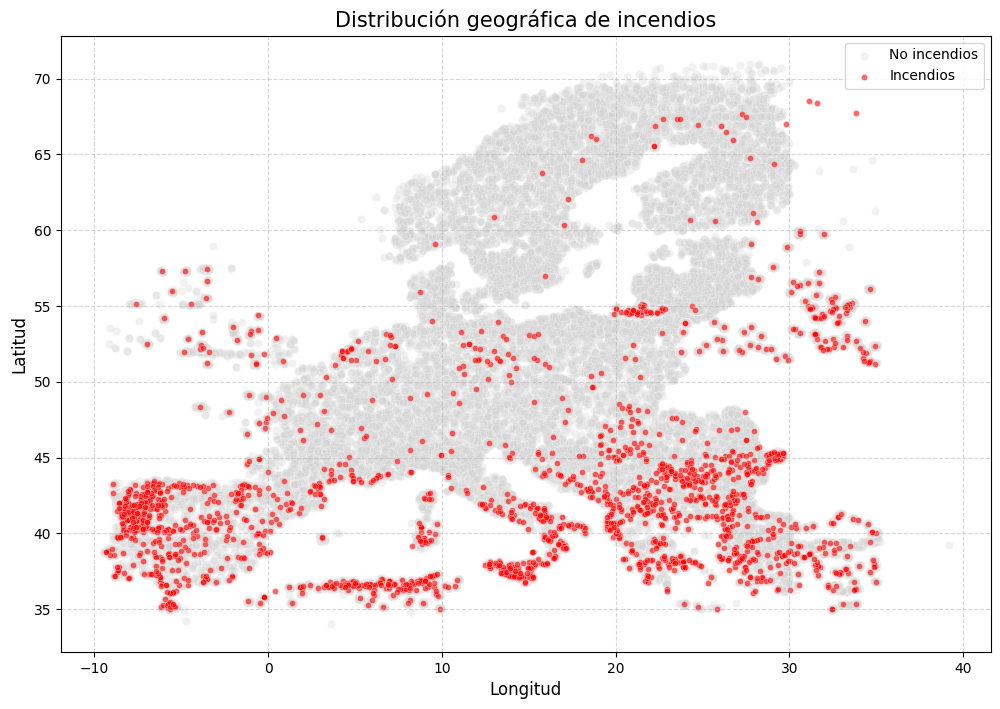

In [27]:
plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_final[df_final['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios')

sns.scatterplot(data=df_final[df_final['final'] == 1], x='lon', y='lat', color='red', alpha=0.6, s=20, label='Incendios')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**DISTRIBUCIÓN DE INCENDIOS POR MESES**

Se quiere evaluar la distribución de los incendios por meses, para conocer qué meses presentan un mayor riesgo de incendio.

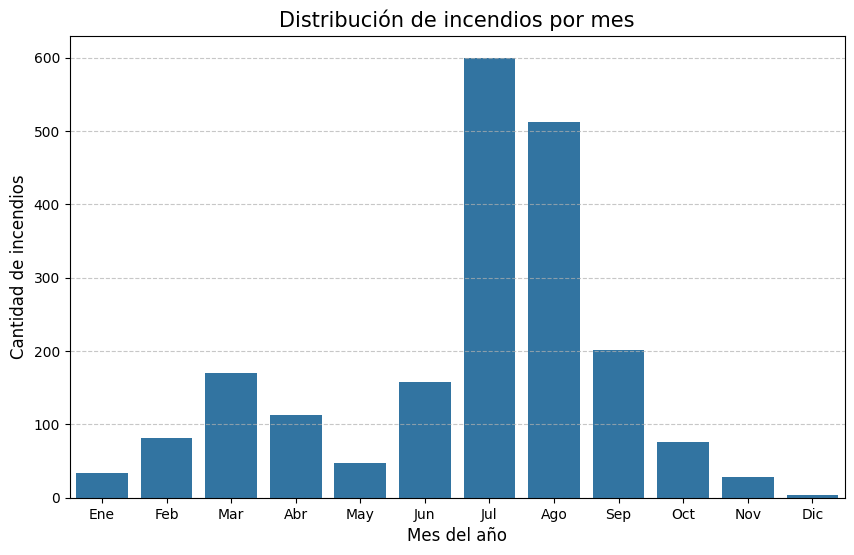

In [28]:
df_final['month'] = df_final['date'].dt.month
df_incendios = df_final[df_final['final'] == 1]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_incendios, x='month')

plt.title('Distribución de incendios por mes', fontsize=15)
plt.xlabel('Mes del año', fontsize=12)
plt.ylabel('Cantidad de incendios', fontsize=12)
plt.xticks(ticks=range(0, 12), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Se observa que la mayoría de incendios se concentran en julio y agosto, principalmente.

**DISTRIBUCIÓN DE LOS INCENDIOS POR AÑO**

[2022 2023 2024 2025]


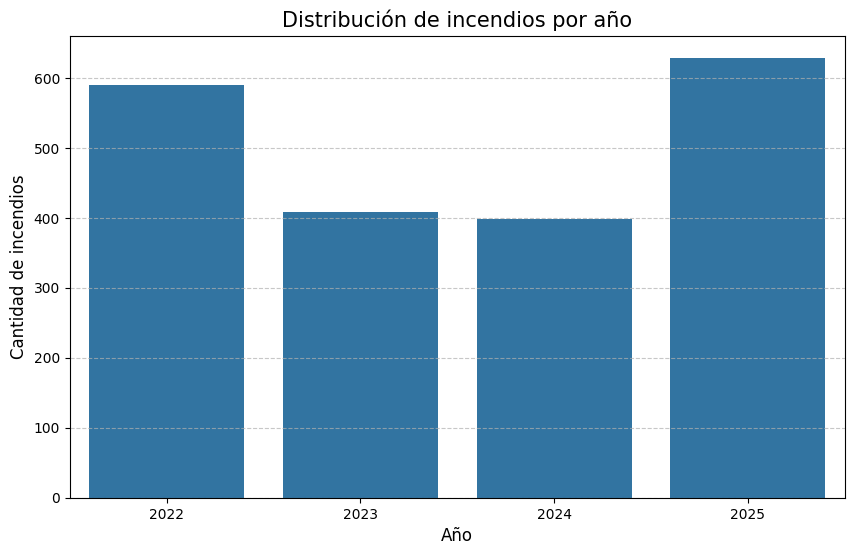

In [12]:
df_dist_anio = df_final.copy()
df_dist_anio['anio'] = df_final['date'].dt.year
df_incendios = df_dist_anio[df_dist_anio['final'] == 1]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_incendios, x='anio')

plt.title('Distribución de incendios por año', fontsize=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de incendios', fontsize=12)
anios = df_dist_anio['anio'].unique()
print(anios)
plt.xticks(ticks=range(0, 4), labels=anios)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**DISTRIBUCIÓN DE LOS DATOS POR MES**

Queremos evaluar si la distribución de los datos es equitativa tras la obtención de datos de no incendio.

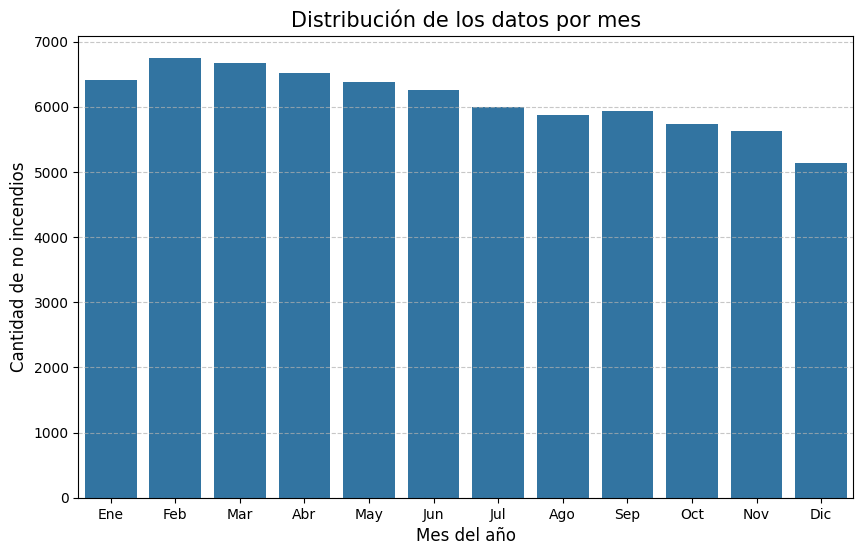

In [32]:
df_distribucion = df_final.copy()
df_distribucion['month'] = df_distribucion['date'].dt.month

plt.figure(figsize=(10, 6))
sns.countplot(data=df_distribucion, x='month')

plt.title('Distribución de los datos por mes', fontsize=15)
plt.xlabel('Mes del año', fontsize=12)
plt.ylabel('Cantidad de no incendios', fontsize=12)
plt.xticks(ticks=range(0, 12), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**DISTRIBUCIÓN DE LOS DATOS POR AÑO**

[2022 2023 2024 2025]


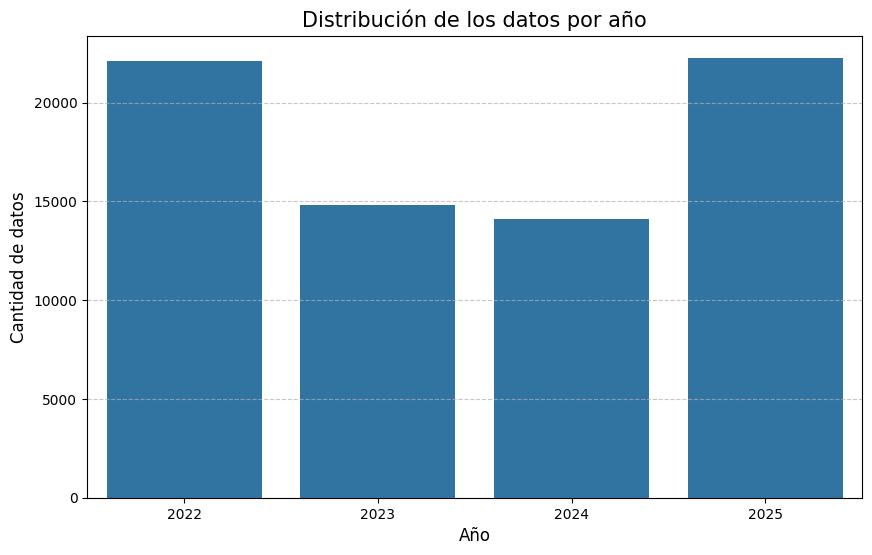

In [ ]:
df_dist_anio = df_final.copy()
df_dist_anio['anio'] = df_dist_anio['date'].dt.year

plt.figure(figsize=(10, 6))
sns.countplot(data=df_dist_anio, x='anio')

plt.title('Distribución de los datos por año', fontsize=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de datos', fontsize=12)
anios = df_dist_anio['anio'].unique()
print(anios)
plt.xticks(ticks=range(0, 4), labels=anios)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**DISTRIBUCIÓN DE LOS DATOS POR MES EN 2025**

[2025]


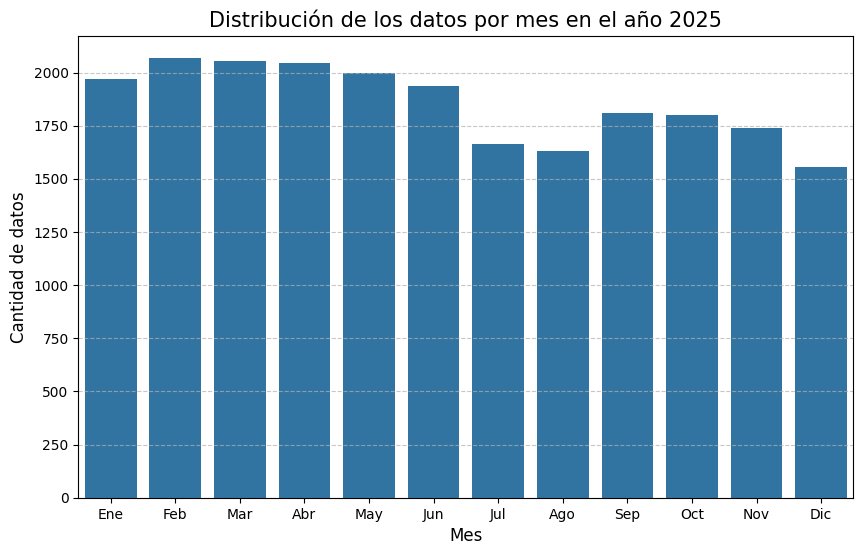

In [22]:
df_dist_anio = df_final.copy()
df_dist_anio['anio'] = df_dist_anio['date'].dt.year
df_dist_anio['month'] = df_dist_anio['date'].dt.month
df_dist_anio = df_dist_anio[df_dist_anio['anio'] == 2025]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_dist_anio, x='month')

plt.title('Distribución de los datos por mes en el año 2025', fontsize=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad de datos', fontsize=12)
print(anios)
plt.xticks(ticks=range(0, 12), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**DISTRIBUCIÓN DE LOS INCENDIOS POR MES EN 2025**

[2025]


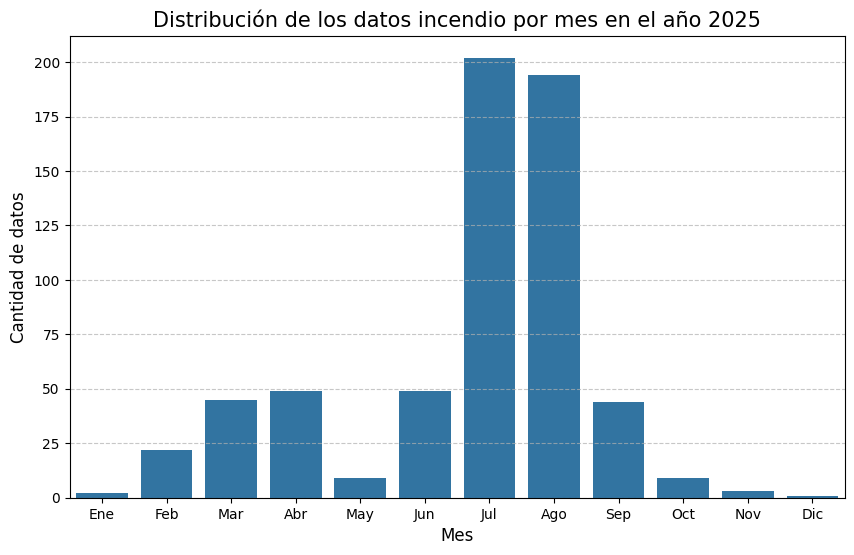

In [26]:
df_dist_anio = df_final.copy()
df_dist_anio['anio'] = df_dist_anio['date'].dt.year
df_dist_anio['month'] = df_dist_anio['date'].dt.month
df_dist_anio = df_dist_anio[df_dist_anio['anio'] == 2025]
df_incendios = df_dist_anio.copy()
df_incendios = df_incendios[df_incendios['final'] == 1]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_incendios, x='month')

plt.title('Distribución de los datos incendio por mes en el año 2025', fontsize=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad de datos', fontsize=12)
print(anios)
plt.xticks(ticks=range(0, 12), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Este último análisis de 2025 se ha hecho para comprobar si el conjunto de test tendría el suficiente número de incendios. Como todos los datos de test son de 2025, y aproximadamente forman parte de él a partir de mayor, habría unos 500 incendios. Se puede comprobar haciendo el split también.

In [7]:
X = df_final.drop(columns=['final'])
y = df_final['final']

X = X.sort_values('date')
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=42)
print("Total de datos:", len(y_test))
print("Total de incendios:", len(y_test[y_test == 1]))

Total de datos: 14665
Total de incendios: 516


**ANÁLISIS ESTRATEGIA DE EVALUACIÖN**

In [9]:
cv_generator = TimeSeriesSplit(n_splits=4)

for i, (train_index, val_index) in enumerate(cv_generator.split(X_train, y_train)):
    y_cv_train = y_train.iloc[train_index]
    y_cv_val = y_train.iloc[val_index]

    total_train = len(y_cv_train)
    incendios_train = len(y_cv_train[y_cv_train == 1])
    perc_train = (incendios_train / total_train) * 100

    total_val = len(y_cv_val)
    incendios_val = len(y_cv_val[y_cv_val == 1])
    perc_val = (incendios_val / total_val) * 100
    
    print(f"--- Split {i + 1} ---")
    print(f"Entrenamiento - Total: {total_train:6d} | Incendios: {incendios_train:4d} ({perc_train:.2f}%)")
    print(f"Validación    - Total: {total_val:6d} | Incendios: {incendios_val:4d} ({perc_val:.2f}%)")
    print("-" * 50)

--- Split 1 ---
Entrenamiento - Total:  11735 | Incendios:  231 (1.97%)
Validación    - Total:  11731 | Incendios:  367 (3.13%)
--------------------------------------------------
--- Split 2 ---
Entrenamiento - Total:  23466 | Incendios:  598 (2.55%)
Validación    - Total:  11731 | Incendios:  392 (3.34%)
--------------------------------------------------
--- Split 3 ---
Entrenamiento - Total:  35197 | Incendios:  990 (2.81%)
Validación    - Total:  11731 | Incendios:  326 (2.78%)
--------------------------------------------------
--- Split 4 ---
Entrenamiento - Total:  46928 | Incendios: 1316 (2.80%)
Validación    - Total:  11731 | Incendios:  194 (1.65%)
--------------------------------------------------


Usar TimeSeriesSplit es mejor porque los datos demuestran que el fenómeno de los incendios no es estable en el tiempo.
Eligiendo un único conjunto de validación, el modelo tendría en cuenta una sola "realidad" (por ejemplo, el 3.34% de incendios del Split 2 o el 1.65% del Split 4). Al validar en 4 momentos distintos, se asegura que modelo sea robusto ante los cambios en la frecuencia de incendios.

**CORRELACIONES ENTRE LAS VARIABLES REGRESORAS**

In [36]:
df2 = df_final.drop(columns=['final', 'date']) #No nos interesa date porque no será empleada en los modelos
df2.corr().style.background_gradient(cmap='coolwarm')

,lat,lon,soil_temp,elevacion_centro,grados,porcentaje,temp_mean,temp_max,temp_min,humidity_mean,precipitation,wind_speed_max,wind_gusts_max,pressure_mean,cloud_cover,radiation,evapotranspiration,sunshine_seconds,NDVI,NDWI,dist_civ
lat,1.000000,0.237769,-0.418696,-0.280591,-0.285875,-0.272119,-0.401743,-0.432315,-0.389080,0.313993,0.003635,0.048097,-0.049505,0.238422,0.302464,-0.306829,-0.339137,-0.225141,-0.069020,0.192023,-0.269091
lon,0.237769,1.000000,-0.125005,-0.179086,-0.246844,-0.239232,-0.126622,-0.126437,-0.139233,-0.010989,-0.069362,-0.010891,-0.104834,0.164694,-0.006374,-0.063136,-0.062641,-0.039636,-0.130821,0.128258,-0.196381
soil_temp,-0.418696,-0.125005,1.000000,-0.009389,0.077748,0.071162,0.957945,0.941364,0.938855,-0.552446,-0.052578,0.029855,0.085756,0.006845,-0.440904,0.736647,0.852578,0.603042,0.251372,-0.321347,0.174388
elevacion_centro,-0.280591,-0.179086,-0.009389,1.000000,0.531436,0.524609,-0.096888,-0.062834,-0.127211,-0.114348,0.028559,-0.197962,0.070362,-0.984683,-0.062120,0.111214,0.036601,0.068372,-0.065681,0.047664,0.092579
grados,-0.285875,-0.246844,0.077748,0.531436,1.000000,0.996414,0.024957,0.032422,0.024973,-0.051232,0.054487,-0.174352,0.099495,-0.524497,-0.054083,0.092866,0.052207,0.063677,0.139277,-0.127191,0.165132
porcentaje,-0.272119,-0.239232,0.071162,0.524609,0.996414,1.000000,0.019068,0.026186,0.018846,-0.047564,0.055031,-0.173205,0.097268,-0.517429,-0.049848,0.088327,0.047540,0.060204,0.130933,-0.117601,0.157024
temp_mean,-0.401743,-0.126622,0.957945,-0.096888,0.024957,0.019068,1.000000,0.984361,0.977128,-0.574183,-0.069184,0.048572,0.074851,0.096490,-0.426403,0.727426,0.854382,0.610785,0.276684,-0.343972,0.153372
temp_max,-0.432315,-0.126437,0.941364,-0.062834,0.032422,0.026186,0.984361,1.000000,0.933621,-0.635692,-0.120020,-0.001116,0.027452,0.069499,-0.497797,0.769540,0.880436,0.668827,0.253906,-0.328771,0.164545
temp_min,-0.389080,-0.139233,0.938855,-0.127211,0.024973,0.018846,0.977128,0.933621,1.000000,-0.466500,-0.006214,0.097183,0.120837,0.121094,-0.331830,0.632722,0.774405,0.512107,0.292402,-0.355098,0.150786
humidity_mean,0.313993,-0.010989,-0.552446,-0.114348,-0.051232,-0.047564,-0.574183,-0.635692,-0.466500,1.000000,0.329894,-0.030224,-0.064987,0.085533,0.620876,-0.700960,-0.796273,-0.651832,0.002410,0.061991,-0.130250


<Axes: >

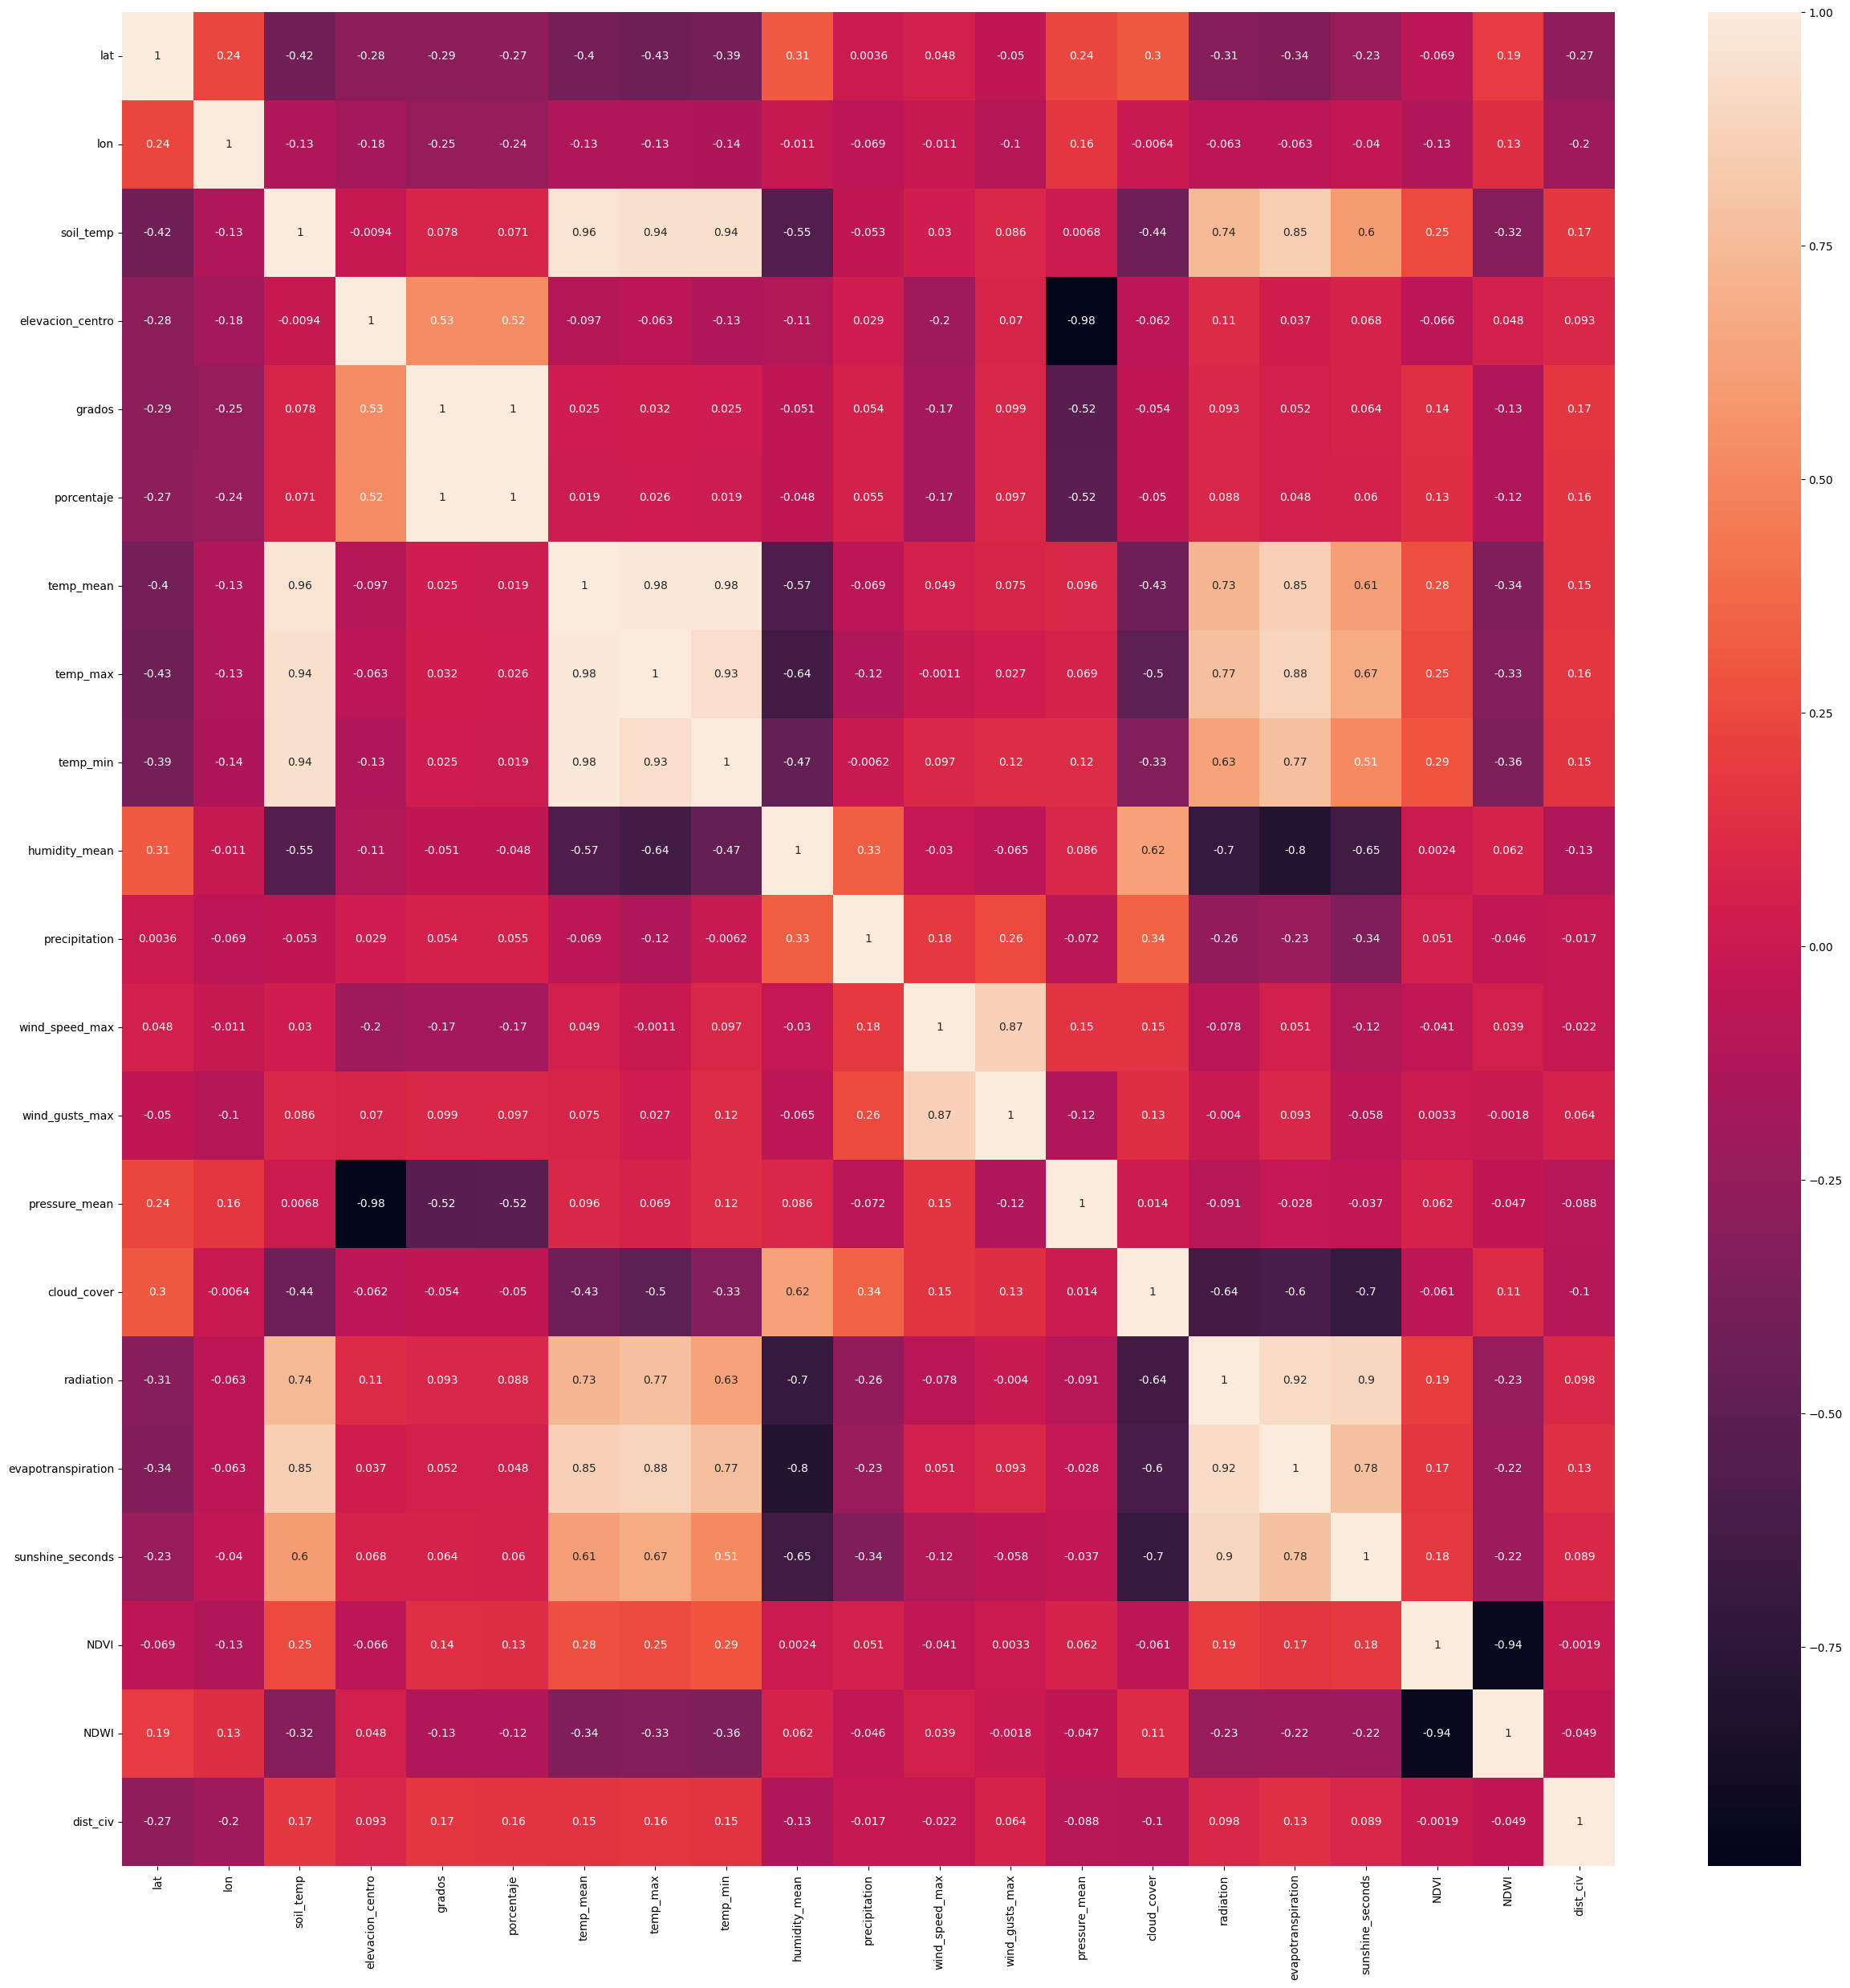

In [37]:
plt.figure(figsize=(30, 30))
sns.heatmap(df2.corr(), annot=True)

**Conclusiones:**

Se observa que hay muchas variables correlacionadas. Destacan:
1. **grados y porcentaje**, con una **correlación de 1**.
2. Las variables que representan la temperatura (**temp_max, temp_min y temp_mean**), con una correlación casi **cercana a 1**.
3. **pressure_mean y elevacion_centro**, con correlación negativa (**-0.98**).
4. **NDVI y NDWI**, con correlación negativa (valor **-0.94**).
5. La correlación de **evapotranspiration y radiation** (con valor **0.92**).
6. La correlación de **radiation con sunshine_seconds** (con valor **0.9**).
7. La correlación de **wind_speed_max y wind_gusts_max**, con una correlación de **0.87**. 
8. **evapotranspiration con temp_mean y temp_max** (con una correlación aproximada de **0.88**). Y de **0.77** con **temp_min**.
9. **evapotranspiration con humidity_mean** (valor **-0.8**).
10. **evapotranspiration con sunshine_seconds** (valor **0.78**).
11. **temp_mean y temp_max con radiation** (valor aproximado de **0.73 y 0.77**).
12. **soil_temp** con las variables de temperatura, con un valor de **0.95** aproximadamente.

La variable evapotranspiration, por tanto, es la que más correlacionada está con el resto de variables. 

También sería importante seleccionar una entre grados o porcentaje, ya que representan lo mismo, entre NDVI y NDWI, entre pressure_mean y elevacion_centro, una entre las dos variables que representan el viento, y una entre todas las variables que representan la temperatura. También se observa alta correlación entre la variable que representa la temperatura del suelo y el resto de variables que representan la temperatura climática.

El resto de correlaciones son menores a 0.7.

**CORRELACIÓN DE LAS VARIABLES REGRESORAS CON LA VARIABLE OBJETIVO**

In [38]:
df3 = df_final.drop(columns = ['date'])
correlaciones = df3.corr()
corr_objetivo = correlaciones['final'].drop(labels=['final']).sort_values(ascending=False)
df_corr_final = corr_objetivo.to_frame(name='Coeficiente de correlación')
df_corr_final

,Coeficiente de correlación
evapotranspiration,0.232719
temp_max,0.186249
soil_temp,0.180709
temp_mean,0.177981
radiation,0.163686
temp_min,0.160286
sunshine_seconds,0.131828
wind_gusts_max,0.060147
wind_speed_max,0.049136
grados,0.030858


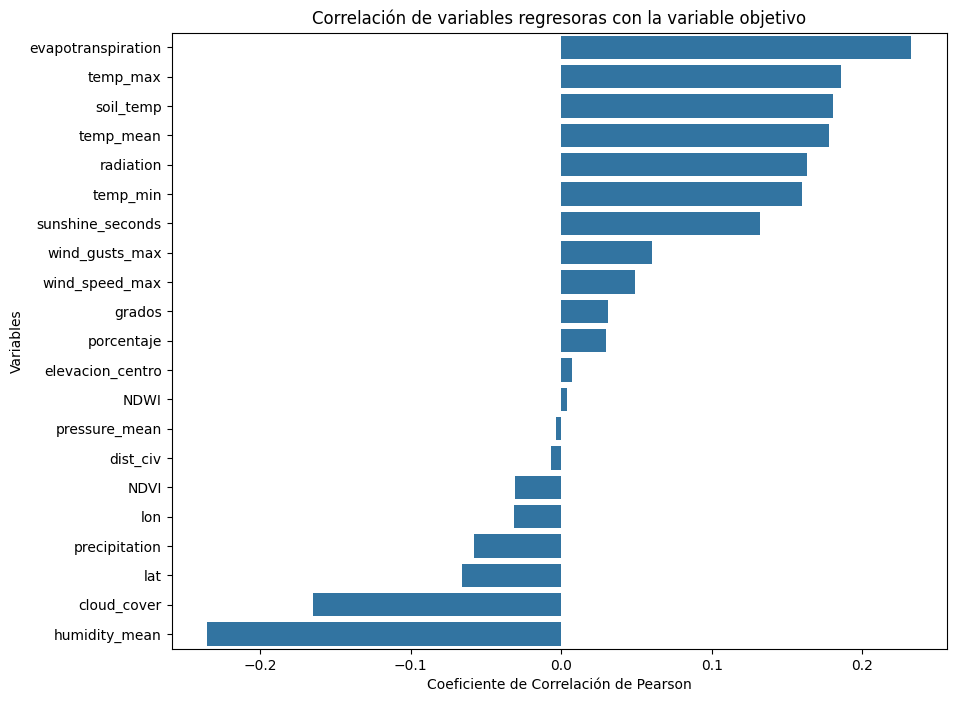

In [39]:
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_objetivo.values, y=corr_objetivo.index)
plt.title('Correlación de variables regresoras con la variable objetivo')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Variables')
plt.show()

**Conclusión:**

Se observa que las variables más correlacionadas con la variable objetivo son evapotranspiration, temp_max, soil_temp, temp_min, temp_mean, radiation, sunshine_seconds (estas con una correlación positiva), y cloud_cover y humidity_mean (con una correlación negativa).